In [28]:
import cupy as cp
import math
import matplotlib.pyplot as plt
from model.network import Network


## Loading the Data

In [29]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596


In [30]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [31]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

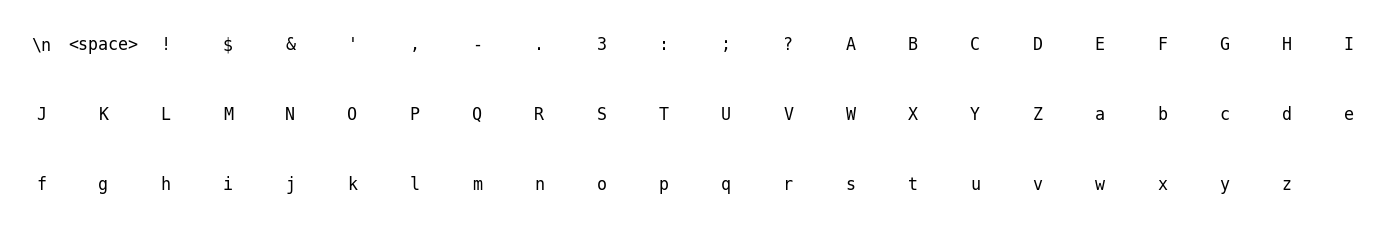

In [32]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [33]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [34]:
embedding_dim = 64
hidden_size = 128

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "Recurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Softmax", "input_size": hidden_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()


Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 64)
  Parameters: 4,160

Layer 2: RecurrentLayer
  Weights Shape: (64, 128) | State Weights Shape: (128, 128) | Biases Shape: (128,)
  Parameters: 24,704

Layer 3: SoftmaxLayer
  Weights Shape: (128, 65) | Biases Shape: (65,)
  Parameters: 8,385

Total Parameters: 37,249


## Training the Model

In [35]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [36]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [37]:
def evaluate(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = network.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [38]:
def train_epoch(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = network.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(network.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        network.backward_sequence(output_errors, batch_size)
        network.update_parameters(learning_rate, weight_decay_lambda, momentum)
        network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [39]:
sequence_length = 64
batch_size = 64
epochs = 500
train_steps_per_epoch = 3072
validation_steps = 1024
base_learning_rate = 0.1
min_learning_rate = 0.001
weight_decay_lambda = 1e-4
momentum = 0.9
early_stopping_patience = 10

In [40]:
epoch_summaries = []

total_steps = epochs * train_steps_per_epoch
global_step = 0

best_model = None
best_perplexity = float("inf")
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

    train_perplexity = train_epoch(
        network=network,
        x_indices=x_train_indices,
        y_indices=y_train_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        learning_rate=learning_rate,
        max_steps=train_steps_per_epoch,
        weight_decay_lambda=weight_decay_lambda,
        momentum=momentum,
    )
    test_perplexity = evaluate(
        network=network,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        max_steps=validation_steps,
    )

    epoch_summary = {
        "epoch": epoch,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if epoch % 50 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = network.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += train_steps_per_epoch

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs due to no improvement.")
        break


{'epoch': 1, 'learning_rate': 0.1, 'train_perplexity': 13.281655040985186, 'test_perplexity': 9.519279340242742}
{'epoch': 50, 'learning_rate': 0.09767247740510235, 'train_perplexity': 5.213820026702036, 'test_perplexity': 5.530302497440858}
{'epoch': 100, 'learning_rate': 0.09072836113943815, 'train_perplexity': 4.826842652247961, 'test_perplexity': 5.303350648900074}
{'epoch': 150, 'learning_rate': 0.07984641259797244, 'train_perplexity': 4.658629415376689, 'test_perplexity': 5.2389731552324115}
{'epoch': 200, 'learning_rate': 0.06609183272293759, 'train_perplexity': 4.555470679936889, 'test_perplexity': 5.195891361535948}
{'epoch': 250, 'learning_rate': 0.050811015626295176, 'train_perplexity': 4.480579635922595, 'test_perplexity': 5.168534129866751}
{'epoch': 300, 'learning_rate': 0.0354997541531777, 'train_perplexity': 4.415350675726255, 'test_perplexity': 5.135048450660172}
{'epoch': 350, 'learning_rate': 0.021656821256405494, 'train_perplexity': 4.362421330642418, 'test_perplexi

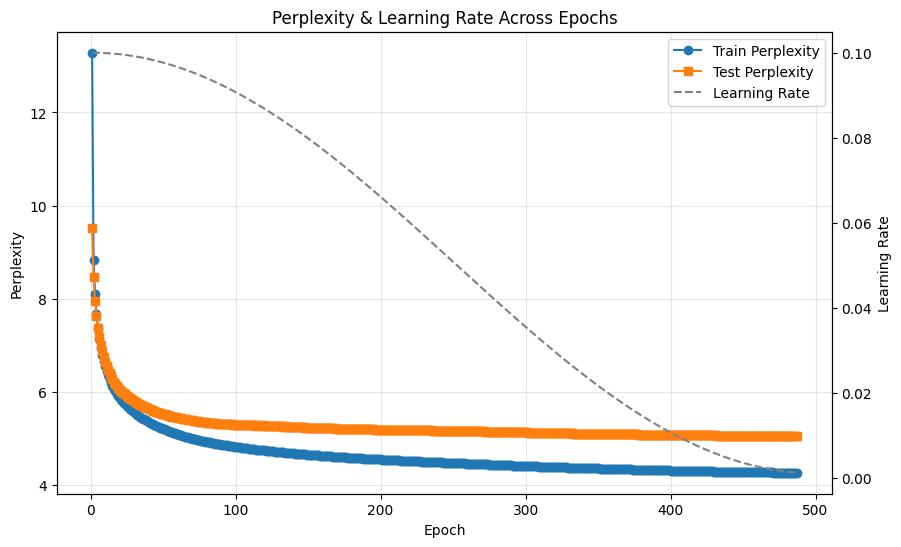

In [41]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
learning_rates = [summary["learning_rate"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, learning_rates, color="gray", linestyle="--", linewidth=1.5, label="Learning Rate")
ax2.set_ylabel("Learning Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("Perplexity & Learning Rate Across Epochs")
plt.show()

In [42]:
def generate_text(
    network: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        network.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        y_prob = network.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

    return "".join(generated)

seed_text = "DANIEL"
print(generate_text(network=network, seed_text=seed_text, length=2000, temperature=0.75))


DANIELA:
Why, but then such as tick am I pile, sir, my sir! that let of our heart, I say the many my do your soon you be of his tongue thou crave
Without not prove the mutited their sweet been mercerful maid, and there's deet.

POLIXENES:
And, the tave thou have haste as a father of a day where in the body would cry, among done, be that here busiss?
Do all and his desires tell to him to gates and we heart, no prison come, I have holight ourself a dukes live my chall as in the daughter nothing world sockolve there is your day be thee up his lawful are these this thought the refell we come down all and your lord, and thou hast disposidest bear alive,
If my canst old not whom through the spo! them with me!

ANTES:
I, if marriet, for thou hadst lawful much sir, I cannot gridy here are being their powers: it feight and where them success and come they know it not a see have out see of him, you process I am such not well with this life of thy worship from cried is the shall you than make and